# Autoencoder MNIST

## Importing required packages

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [2]:
transforms=transforms.ToTensor()

## Downloading requried data

In [3]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

## Defining dataloaders

In [4]:
valid_size=0.2

# IMPORTANT 
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

In [5]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [6]:
# checking our data
dataiter=iter(train_loader)
images,labels=next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels,labels.shape,len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

## Visualizing a Training batch

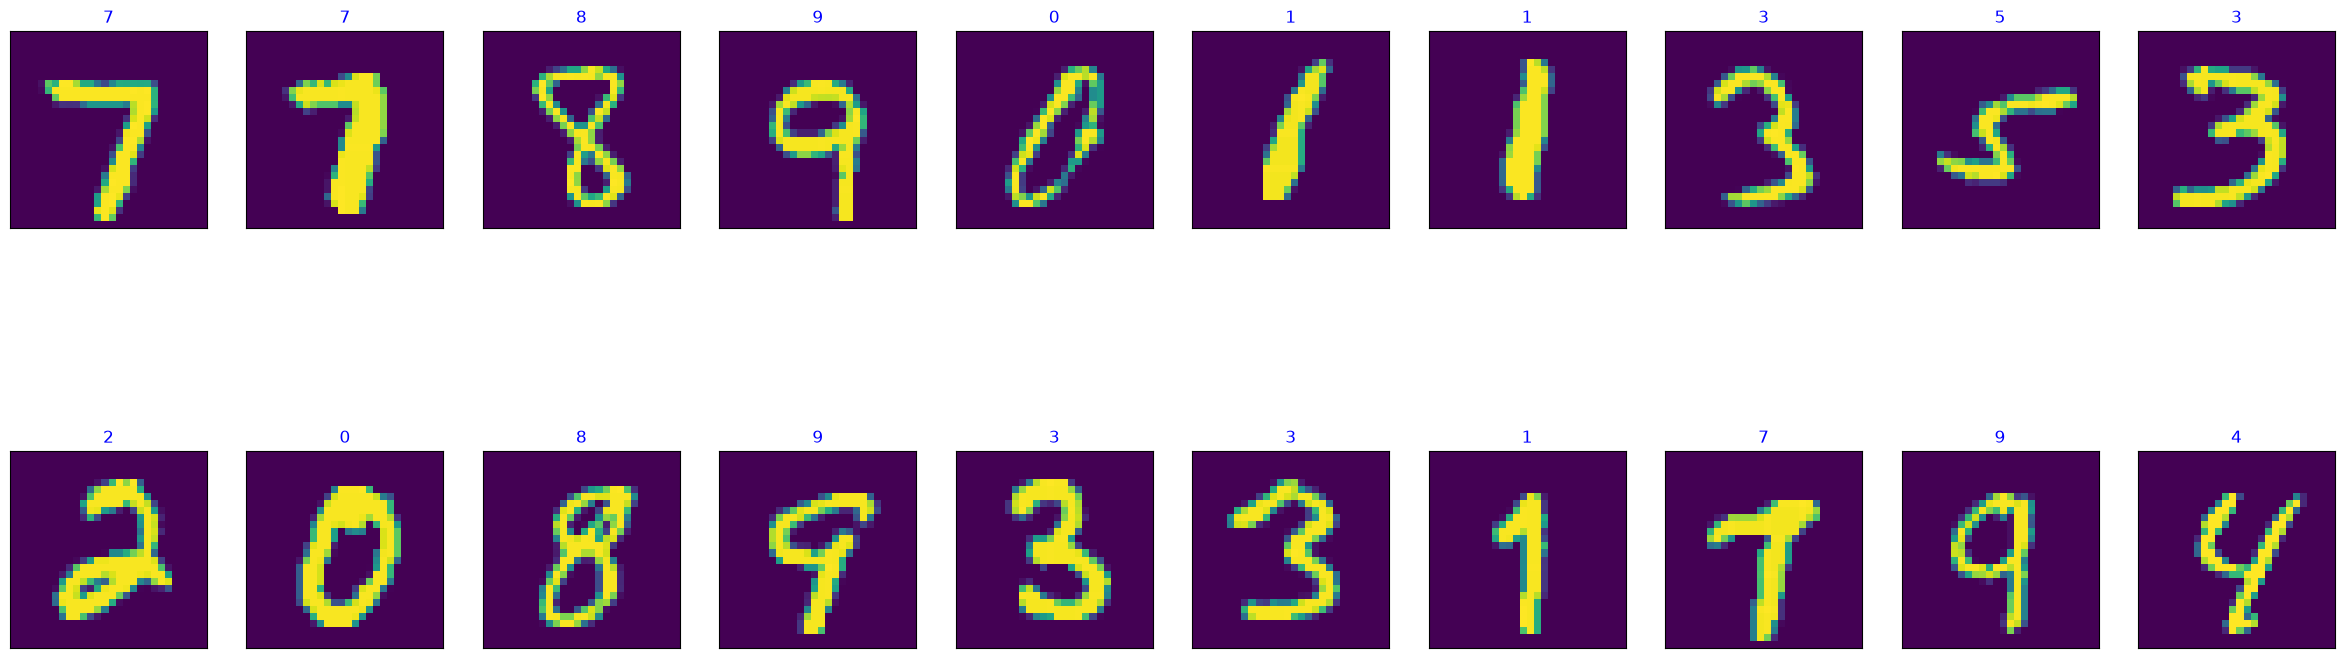

In [7]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Adding Noise (Denoising Autoencoder)

We create noisy versions of the input images by adding random Gaussian noise, then clip pixel values back to the valid `[0, 1]` range. The model will be trained to map **noisy image -> clean image**, which is the core denoising task.

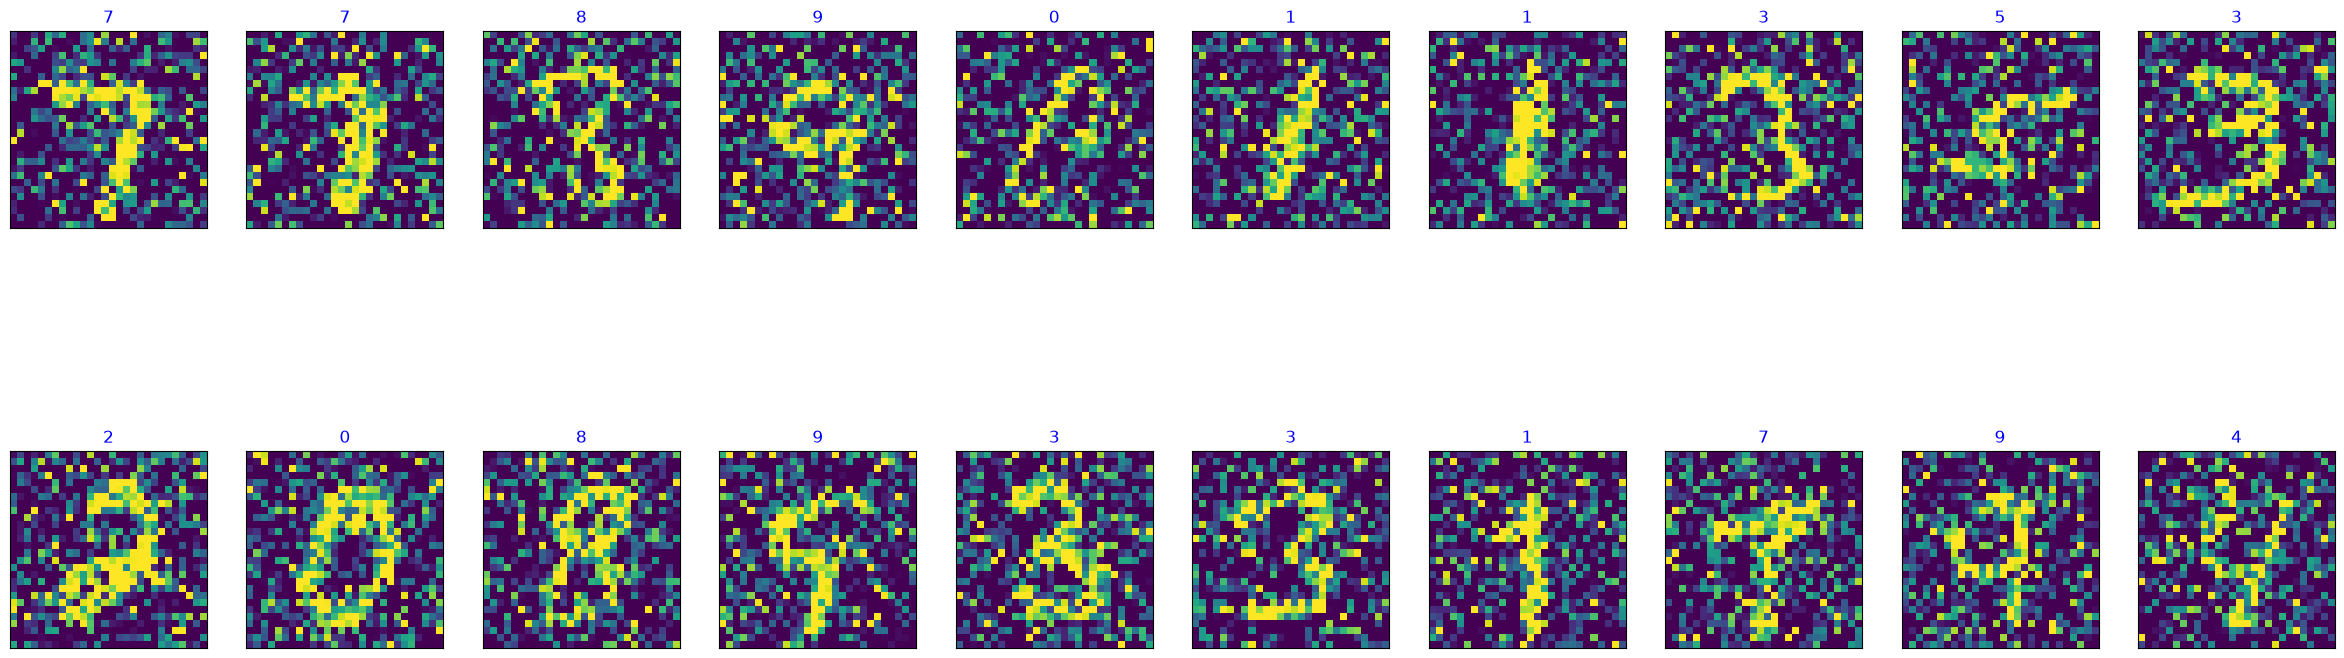

In [8]:
# Amount of noise to add. Higher = harder denoising task.
noise_factor = 0.5

def add_noise(imgs, noise_factor=noise_factor):
    """Adds Gaussian noise to a batch of images and clips to [0, 1]."""
    noisy_imgs = imgs + noise_factor * torch.randn(*imgs.shape)
    noisy_imgs = torch.clip(noisy_imgs, 0., 1.)
    return noisy_imgs

# Visualizing a noisy version of the same batch shown above
noisy_images = add_noise(images)

fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(noisy_images[i]))
    ax.set_title(labels[i].item(),color='blue')


## Defining Architecture

In [9]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)
    
    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [10]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

## Defining our Loss Function

In [11]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [12]:
def trainNet(model,lr,state='fully'):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)

    # Number of epochs to train for
    loss_keeper={'train':[],'valid':[]}
    epochs=20

    # minimum validation loss ----- set initial minimum to infinity
    valid_loss_min = np.inf 

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        """
        TRAINING PHASE
        """
        model.train() # TURN ON DROPOUT for training
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()
            # clean images are the targets; noisy images are the model input
            noisy_images = add_noise(images)
            if state=='fully':
                images=images.view(images.size(0),-1)
                noisy_images=noisy_images.view(noisy_images.size(0),-1)
            optimizer.zero_grad()
            output=model(noisy_images)
            loss=criterion(output,images)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        """
        VALIDATION PHASE
        """
        model.eval() # TURN OFF DROPOUT for validation
        for images,_ in valid_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()
            noisy_images = add_noise(images)
            if state=='fully':
                images=images.view(images.size(0),-1)
                noisy_images=noisy_images.view(noisy_images.size(0),-1)
            output=model(noisy_images)
            loss=criterion(output,images)
            valid_loss+=loss.item()

        # Calculating loss over entire batch size for every epoch
        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)


        # saving loss values
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model.......")
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)


In [13]:
m1_loss=trainNet(model_1,0.01)


Epoch : 1	Training Loss : 0.043799434149016936	Validation Loss : 0.04097183203945557
Validation loss decreased from : inf ----> 0.04097183203945557 ----> Saving Model.......

Epoch : 2	Training Loss : 0.04054767630761489	Validation Loss : 0.040803330863515536
Validation loss decreased from : 0.04097183203945557 ----> 0.040803330863515536 ----> Saving Model.......

Epoch : 3	Training Loss : 0.039931248874248315	Validation Loss : 0.039700144839783506
Validation loss decreased from : 0.040803330863515536 ----> 0.039700144839783506 ----> Saving Model.......

Epoch : 4	Training Loss : 0.03973351917928085	Validation Loss : 0.04023656349008282

Epoch : 5	Training Loss : 0.03971329215914011	Validation Loss : 0.039512229713921744
Validation loss decreased from : 0.039700144839783506 ----> 0.039512229713921744 ----> Saving Model.......

Epoch : 6	Training Loss : 0.03965869798247392	Validation Loss : 0.039240752328187224
Validation loss decreased from : 0.039512229713921744 ----> 0.0392407523281

In [14]:
m2_loss=trainNet(model_2,0.01,'conv')


Epoch : 1	Training Loss : 0.038523110200961434	Validation Loss : 0.0340660389016072
Validation loss decreased from : inf ----> 0.0340660389016072 ----> Saving Model.......

Epoch : 2	Training Loss : 0.03309058309067041	Validation Loss : 0.03253692547790706
Validation loss decreased from : 0.0340660389016072 ----> 0.03253692547790706 ----> Saving Model.......

Epoch : 3	Training Loss : 0.03232842519724121	Validation Loss : 0.03201865140038232
Validation loss decreased from : 0.03253692547790706 ----> 0.03201865140038232 ----> Saving Model.......

Epoch : 4	Training Loss : 0.03212452799237023	Validation Loss : 0.032413090026626984

Epoch : 5	Training Loss : 0.03199426206837719	Validation Loss : 0.03218537829816341

Epoch : 6	Training Loss : 0.03191426153372352	Validation Loss : 0.03179691401310265
Validation loss decreased from : 0.03201865140038232 ----> 0.03179691401310265 ----> Saving Model.......

Epoch : 7	Training Loss : 0.031819889069690056	Validation Loss : 0.03246695736733576



In [15]:
m3_loss=trainNet(model_3,0.01,'conv')

C:\Users\ayush\AppData\Local\Temp\ipykernel_5052\219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
C:\Users\ayush\AppData\Local\Temp\ipykernel_5052\219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.11219270763918758	Validation Loss : 0.11181262167791525
Validation loss decreased from : inf ----> 0.11181262167791525 ----> Saving Model.......

Epoch : 2	Training Loss : 0.11205006895897289	Validation Loss : 0.11181262115637461
Validation loss decreased from : 0.11181262167791525 ----> 0.11181262115637461 ----> Saving Model.......

Epoch : 3	Training Loss : 0.11205006900243461	Validation Loss : 0.1118126214419802

Epoch : 4	Training Loss : 0.11205006901795665	Validation Loss : 0.11181262152890364

Epoch : 5	Training Loss : 0.11205006895276408	Validation Loss : 0.11181262120604515

Epoch : 6	Training Loss : 0.11205006912661096	Validation Loss : 0.11181262155373892

Epoch : 7	Training Loss : 0.11205006881306569	Validation Loss : 0.11181262135505676

Epoch : 8	Training Loss : 0.11205006903968752	Validation Loss : 0.1118126218765974

Epoch : 9	Training Loss : 0.1120500689620773	Validation Loss : 0.11181262106945117
Validation loss decreased from : 0.111812621

In [16]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth'))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth'))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth'))

<All keys matched successfully>

## Plotting Loss

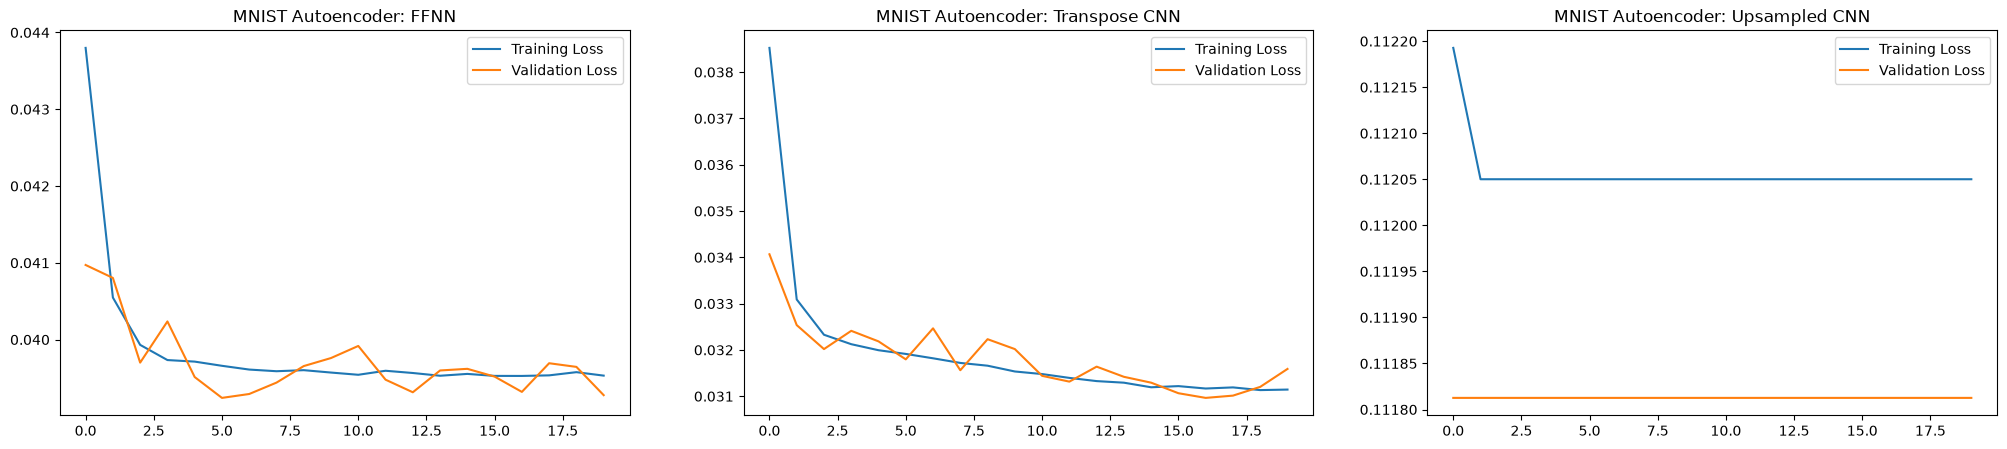

In [17]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [18]:
def test(model,state='fully'):
    # obtain one batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    if use_cuda and torch.cuda.is_available():
        images=images.cuda()

    # create the noisy version that is actually fed to the model
    noisy_images = add_noise(images)

    model_input = noisy_images
    if state=='fully':
        model_input = noisy_images.view(noisy_images.size(0), -1)

    # get sample outputs (denoised reconstructions)
    output = model(model_input)
    # prep images for display
    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    # output is resized into a batch of images
    output = output.view(batch_size, 1, 28, 28)
    # use detach when it's an output that requires_grad
    output = output.cpu().detach().numpy()


    # plot original, noisy, and denoised images: one row each
    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25,6))

    row_labels = ['Original', 'Noisy', 'Denoised']
    for row_idx, (imgs, row) in enumerate(zip([images, noisy_images, output], axes)):
        for img, ax in zip(imgs, row):
            if state=='fully':
                img = img.reshape(1, 28, 28)
            ax.imshow(np.squeeze(img), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
        row[0].set_ylabel(row_labels[row_idx], fontsize=14, rotation=90, labelpad=10)
        row[0].get_yaxis().set_visible(True)
        row[0].set_yticks([])


## FFNN Autoencoder

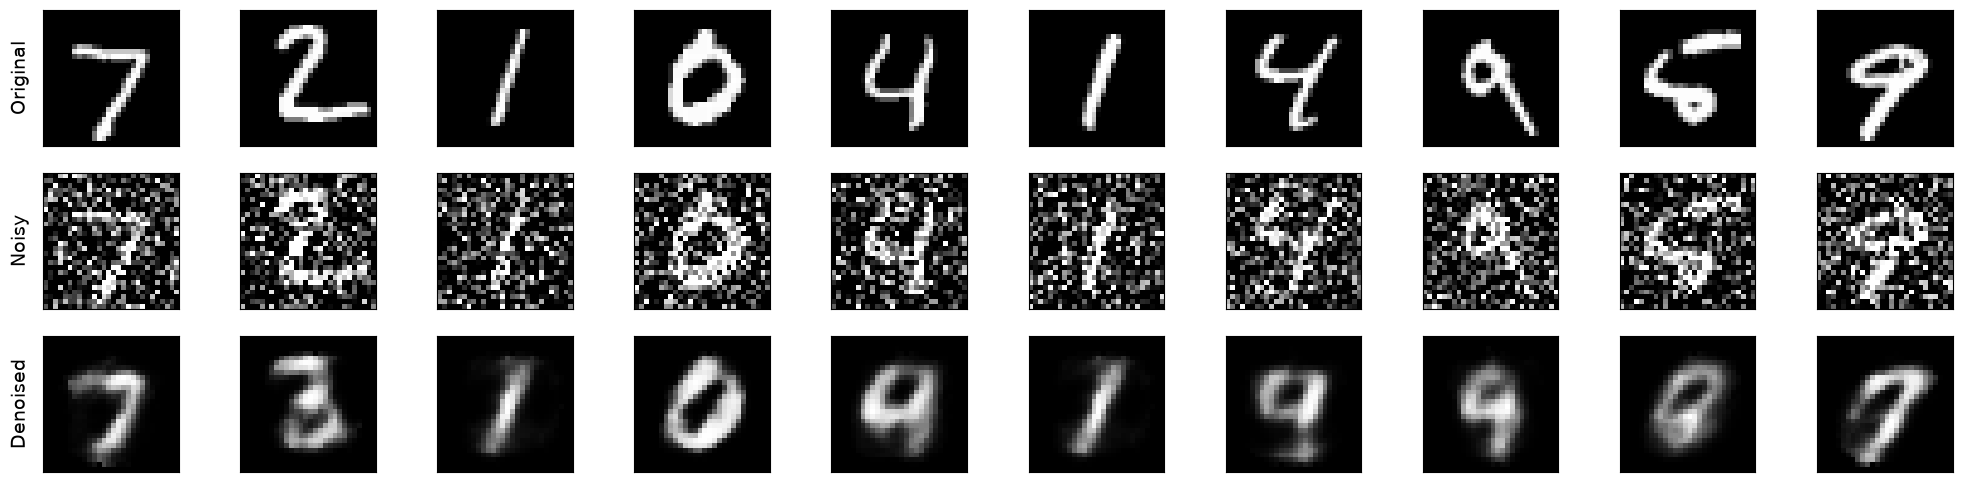

In [19]:
test(model_1)

## Transpose CNN Autoencoder

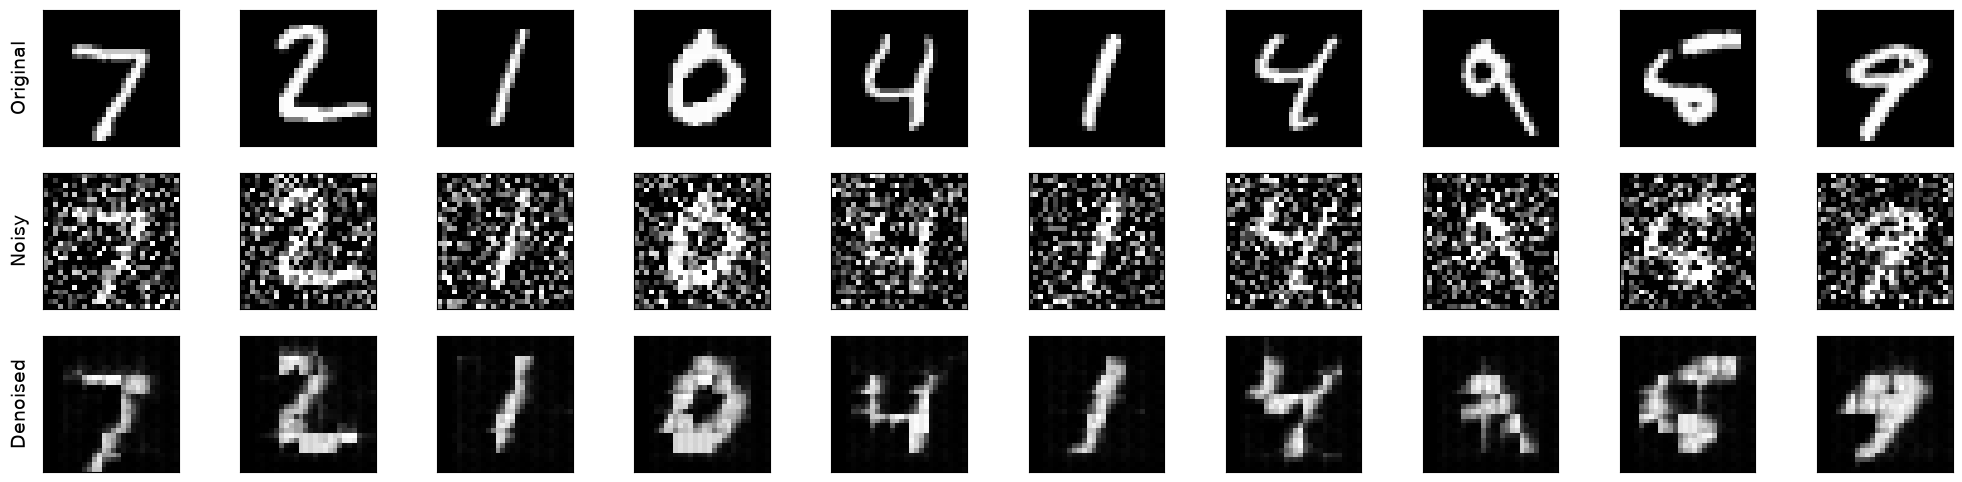

In [20]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

C:\Users\ayush\AppData\Local\Temp\ipykernel_5052\219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
C:\Users\ayush\AppData\Local\Temp\ipykernel_5052\219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')


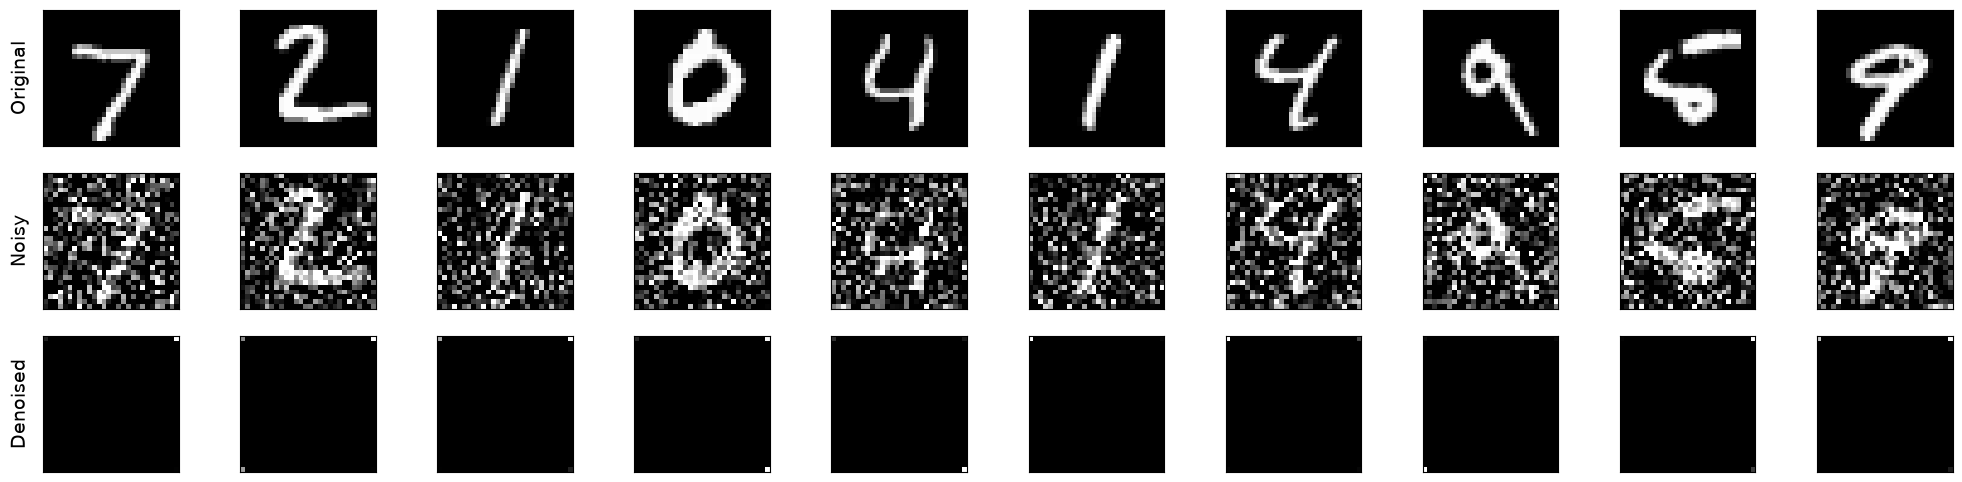

In [21]:
test(model_3,'conv')

## Observations & Analysis

I trained all three models for 20 epochs using noisy images as input and the clean originals as targets. Here's what I found.

**Final validation loss (MSE) after 20 epochs:**

| Model | Val Loss (Epoch 1) | Val Loss (Epoch 20, best) | Trend |
|---|---|---|---|
| FFNN | 0.0410 | ~0.0393 (plateaued after epoch 3) | Improves briefly, then stalls |
| Transpose CNN | 0.0341 | 0.0310 (still improving) | Steady, consistent decrease |
| Upsampled CNN | 0.1118 | 0.1118 (unchanged) | Flat / did not learn |

**Denoising performance:** The transpose CNN autoencoder ended up being the best of the three. Its validation loss went from about 0.034 down to 0.031 and was still dropping when training stopped at epoch 20, so it probably would've kept improving with more epochs. Looking at the output images, the digits came out fairly clean and you could still make out the shapes clearly even with the noise added. The FFNN did okay but not great — loss dropped fast in the first 3 epochs (0.041 to about 0.0395) and then basically flatlined for the rest of training. I think that's because the encoder is just one linear layer with 32 units, not much room to actually learn how to separate noise from the real digit pattern. The reconstructions look blurry, so it's denoising a bit but losing detail. The upsampled CNN, on the other hand, didn't really learn anything — more on that below.

**Effect of noise_factor:** I used a noise_factor of 0.5, which was strong enough that the noisy images were genuinely hard to read even for me. If I lower it, the models would probably all look better since there's less to remove. If I push it higher, I'd expect the gap between the transpose CNN and the other two to get even more obvious, since the weaker models likely wouldn't hold up as well under heavier noise.

**Training behavior:** None of the models seemed to be overfitting — training and validation loss stayed close together throughout for all three. If anything, the FFNN and upsampled CNN were underfitting, since they just stopped improving partway through instead of continuing to learn.

**Challenges faced:** The biggest issue was the upsampled CNN model. Its loss basically never moved the entire time, staying around 0.112 from epoch 1 to epoch 20. When I looked at the actual output images, it's not really reconstructing digits at all — it looks more like it's outputting close to a blank/constant image no matter what the input is, so it basically didn't learn anything useful. I don't think it's a bug in the data pipeline, since the other two models trained fine on the exact same data, so it's more likely a training issue — maybe the learning rate (0.01) was too high for this architecture and it got stuck early. I'd want to try a lower learning rate like 0.001 next time to see if that fixes it. Separately, the original notebook code also had a few outdated function calls that don't work with current library versions (np.Inf, F.sigmoid, F.upsample, and dataiter.next()), so I had to update those before anything would even run.

**Key takeaways:** If I had to pick one model for this task it'd be the transpose CNN — it gave the cleanest results and was the only one that hadn't plateaued yet by the end of training. The upsampled CNN needs more tuning before it's usable, and the FFNN is limited by its simple architecture no matter how long you train it.